Exercice 1

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('ventes_commerces.csv')

print(f"Nombre de lignes : {len(df)}")
print(f"Nombre de colonnes : {df.shape[1]}")
print(f"\nTypes de données :\n{df.dtypes}")
print(df.isnull().sum())


Nombre de lignes : 1000
Nombre de colonnes : 8

Types de données :
date              object
produit_id         int64
categorie         object
prix_unitaire    float64
quantite           int64
region            object
client_id          int64
montant_total    float64
dtype: object
date             0
produit_id       0
categorie        0
prix_unitaire    0
quantite         0
region           0
client_id        0
montant_total    0
dtype: int64


Exercice 2

In [2]:
print(df.isnull().sum())
nb_doublons = df.duplicated().sum()
print("Nombre de doublons exacts :", nb_doublons)


date             0
produit_id       0
categorie        0
prix_unitaire    0
quantite         0
region           0
client_id        0
montant_total    0
dtype: int64
Nombre de doublons exacts : 0


Exercice 3

In [3]:
doublons = df.duplicated()
doublons

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Length: 1000, dtype: bool

In [4]:
df_sans_doublons = df.drop_duplicates()
df_sans_doublons

,date,produit_id,categorie,prix_unitaire,quantite,region,client_id,montant_total
0,2023-01-01,7,Meuble,37.56,2,Centre,336,75.12
1,2023-01-02,20,Vetement,64.03,2,Ouest,153,128.06
2,2023-01-03,15,Meuble,70.62,2,Sud,237,141.24
3,2023-01-04,11,Vetement,52.17,2,Nord,432,104.34
4,2023-01-05,8,Electronique,59.25,5,Est,371,296.25
...,...,...,...,...,...,...,...,...
995,2025-09-22,3,Sport,69.16,4,Sud,221,276.64
996,2025-09-23,20,Electronique,65.59,4,Est,433,262.36
997,2025-09-24,11,Alimentation,44.19,4,Centre,302,176.76
998,2025-09-25,6,Meuble,78.22,1,Est,128,78.22


Exercice 4

In [5]:
Q1 = df_sans_doublons['prix_unitaire'].quantile(0.25)
Q3 = df_sans_doublons['prix_unitaire'].quantile(0.75)
IQR = Q3 - Q1

print(f"Q1 : {Q1}, Q3 : {Q3}, IQR : {IQR}")

seuil_bas = Q1 - 1.5 * IQR
seuil_haut = Q3 + 1.5 * IQR

print(f"Seuils : [{seuil_bas}, {seuil_haut}]")

outliers = df[(df_sans_doublons['prix_unitaire'] < seuil_bas) | (df_sans_doublons['prix_unitaire'] > seuil_haut)]
print(f"\nNombre d'outliers : {len(outliers)}")
print(outliers[['produit_id', 'prix_unitaire']].head())


Q1 : 35.897499999999994, Q3 : 62.6075, IQR : 26.710000000000008
Seuils : [-4.167500000000018, 102.67250000000001]

Nombre d'outliers : 6
     produit_id  prix_unitaire
349           6         103.26
521          13         103.75
559           3         104.62
604           1         103.56
708          18         104.32


In [6]:
Q1 = df_sans_doublons['montant_total'].quantile(0.25)
Q3 = df_sans_doublons['montant_total'].quantile(0.75)
IQR = Q3 - Q1

print(f"Q1 : {Q1}, Q3 : {Q3}, IQR : {IQR}")

seuil_bas = Q1 - 1.5 * IQR
seuil_haut = Q3 + 1.5 * IQR

print(f"Seuils : [{seuil_bas}, {seuil_haut}]")

outliers = df[(df_sans_doublons['montant_total'] < seuil_bas) | (df_sans_doublons['montant_total'] > seuil_haut)]
print(f"\nNombre d'outliers : {len(outliers)}")
print(outliers[['produit_id', 'montant_total']].head())


Q1 : 69.065, Q3 : 199.79250000000002, IQR : 130.72750000000002
Seuils : [-127.02625000000003, 395.8837500000001]

Nombre d'outliers : 29
     produit_id  montant_total
11            3         507.24
18           12         490.02
64            8         695.10
101          12         418.74
135          13         547.44


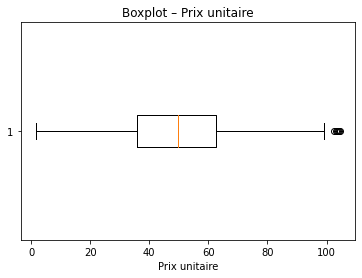

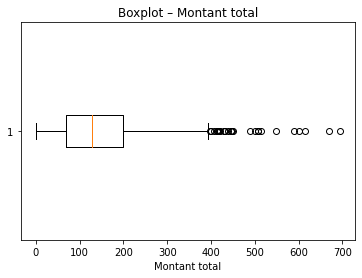

In [7]:
import matplotlib.pyplot as plt

plt.figure()
plt.boxplot(df_sans_doublons["prix_unitaire"], vert=False)
plt.title("Boxplot – Prix unitaire")
plt.xlabel("Prix unitaire")
plt.show()

plt.figure()
plt.boxplot(df_sans_doublons["montant_total"], vert=False)
plt.title("Boxplot – Montant total")
plt.xlabel("Montant total")
plt.show()


Exercice 5

Pas nécessaire car il n'y a pas de doublons exactes ni de valeurs manquantes donc la taille du dataframe ne changera pas 